In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from dython.nominal import associations


In [2]:
df = pd.read_csv('../artifacts/raw.csv',parse_dates=['Date'])

C:\Users\Dhvanish\AppData\Local\Temp\ipykernel_6328\2408297586.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../artifacts/raw.csv',parse_dates=['Date'])


In [3]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [15]:
df['StateHoliday'].value_counts()

StateHoliday
0    592943
0    393216
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [20]:
for col in df.columns:
    print(df[col].value_counts())

Store
1115    942
1       942
2       942
3       942
4       942
       ... 
32      758
36      758
41      758
1092    758
1094    758
Name: count, Length: 1115, dtype: int64
DayOfWeek
5    145845
4    145845
3    145665
2    145664
1    144730
7    144730
6    144730
Name: count, dtype: int64
Date
2013-01-02    1115
2015-07-31    1115
2015-07-30    1115
2015-07-29    1115
2015-07-28    1115
              ... 
2014-12-28     935
2014-12-26     935
2014-12-25     935
2014-12-24     935
2014-12-23     935
Name: count, Length: 942, dtype: int64
Sales
0        172871
5674        215
5558        197
5483        196
6049        195
          ...  
23861         1
22756         1
24520         1
24144         1
24287         1
Name: count, Length: 21734, dtype: int64
Customers
0       172869
560       2414
576       2363
603       2337
571       2330
         ...  
3733         1
4566         1
3908         1
3809         1
3215         1
Name: count, Length: 4086, dtype: int64
Open
1    8

In [49]:
df.sample(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
177409,125,7,2015-02-22,0,0,0,0,0,0,a,a,760.0,12.0,2005.0,0,NaN,NaN,NaN
235495,231,4,2015-01-01,0,0,0,0,a,1,d,c,3840.0,10.0,2008.0,1,39.0,2010.0,"Feb,May,Aug,Nov"
246289,673,7,2014-12-21,0,0,0,0,0,0,d,c,15170.0,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
742136,332,3,2013-09-04,3265,507,1,0,0,0,a,a,1840.0,3.0,2006.0,0,NaN,NaN,NaN
604477,933,1,2014-01-06,11580,1250,1,1,0,0,a,c,6270.0,2.0,2005.0,0,NaN,NaN,NaN
360483,822,4,2014-08-21,9790,711,1,1,0,1,a,c,410.0,11.0,2010.0,1,48.0,2010.0,"Mar,Jun,Sept,Dec"
990305,971,5,2013-01-25,8459,983,1,1,0,0,c,a,1140.0,5.0,2011.0,1,14.0,2012.0,"Mar,Jun,Sept,Dec"
563708,304,2,2014-02-11,6134,1088,1,0,0,0,a,a,1950.0,7.0,2015.0,0,NaN,NaN,NaN
203981,1052,5,2015-01-30,10450,925,1,1,0,0,a,c,5080.0,NaN,NaN,1,31.0,2013.0,"Feb,May,Aug,Nov"
947029,65,1,2013-03-04,7967,651,1,1,0,0,a,c,13840.0,5.0,2010.0,1,1.0,2012.0,"Jan,Apr,Jul,Oct"


In [23]:
df.shape

(1017209, 18)

In [24]:
df['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [25]:
df['StateHoliday'].value_counts()

StateHoliday
0    592943
0    393216
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [26]:
df['StoreType'].value_counts()

StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

In [27]:
df['Assortment'].value_counts()

Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64

In [31]:
print(df['CompetitionDistance'].min())
print(df['CompetitionDistance'].max())
print(df['CompetitionDistance'].nunique())

20.0
75860.0
654


In [29]:
df['CompetitionOpenSinceMonth'].value_counts()

CompetitionOpenSinceMonth
9.0     114254
4.0      87076
11.0     84455
3.0      63548
7.0      59434
12.0     57896
10.0     55622
6.0      45444
5.0      39608
2.0      37886
8.0      36186
1.0      12452
Name: count, dtype: int64

In [32]:
df['CompetitionOpenSinceYear'].value_counts()

CompetitionOpenSinceYear
2013.0    75426
2012.0    74299
2014.0    63732
2005.0    56564
2010.0    51258
2011.0    49396
2009.0    49396
2008.0    48476
2007.0    43744
2006.0    42802
2015.0    35060
2002.0    24882
2004.0    19804
2003.0    16794
2001.0    14704
2000.0     9236
1999.0     7352
1990.0     4710
1994.0     1884
1995.0     1700
1961.0      942
1998.0      942
1900.0      758
Name: count, dtype: int64

In [33]:
df['Promo'].value_counts()

Promo
0    629129
1    388080
Name: count, dtype: int64

In [34]:
df['PromoInterval'].value_counts()

PromoInterval
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64

In [5]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

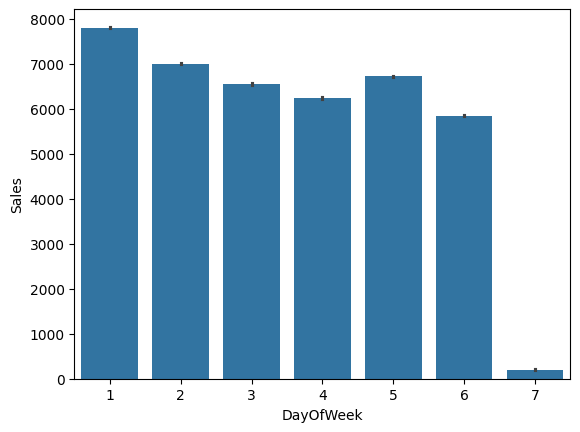

In [41]:
sns.barplot(data=df,x='DayOfWeek',y='Sales')

<Axes: xlabel='Promo', ylabel='Sales'>

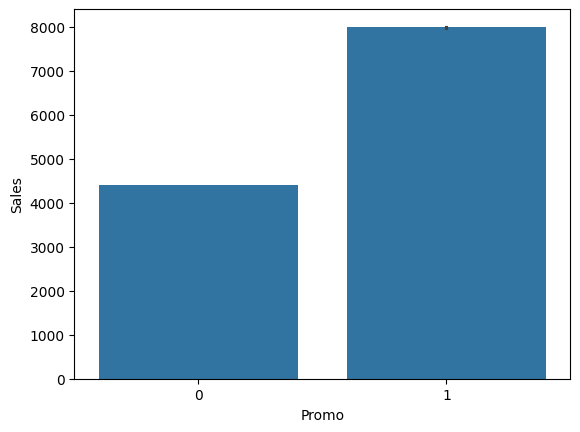

In [42]:
sns.barplot(data=df,x='Promo',y='Sales')

<Axes: xlabel='StateHoliday', ylabel='Sales'>

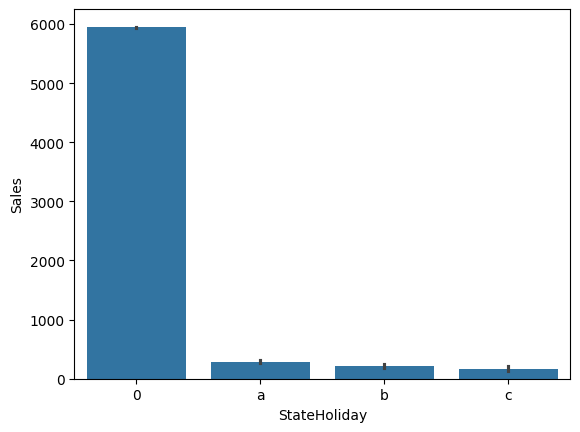

In [44]:
sns.barplot(data=df,x='StateHoliday',y='Sales')

<Axes: xlabel='SchoolHoliday', ylabel='Sales'>

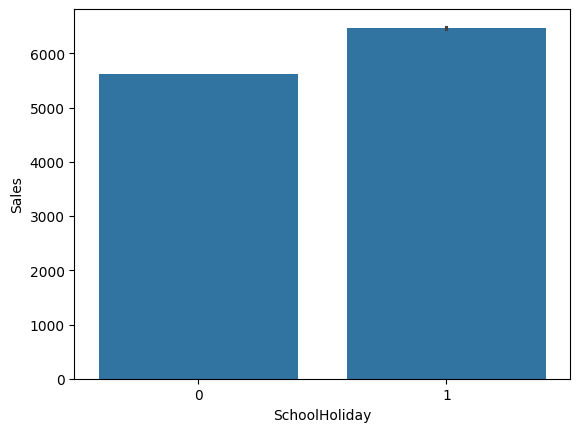

In [45]:
sns.barplot(data=df,x='SchoolHoliday',y='Sales')

<Axes: xlabel='StoreType', ylabel='Sales'>

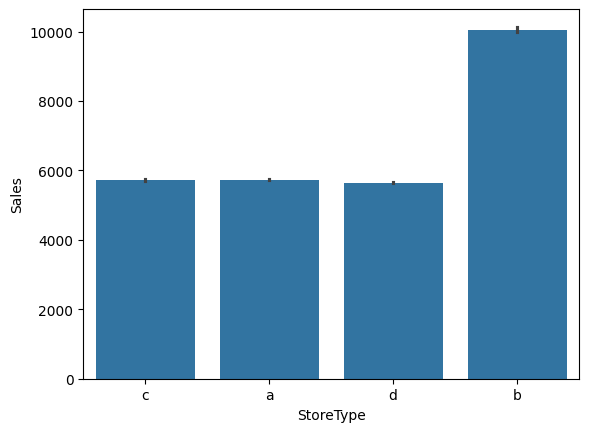

In [46]:
sns.barplot(data=df,x='StoreType',y='Sales')

<Axes: xlabel='Assortment', ylabel='Sales'>

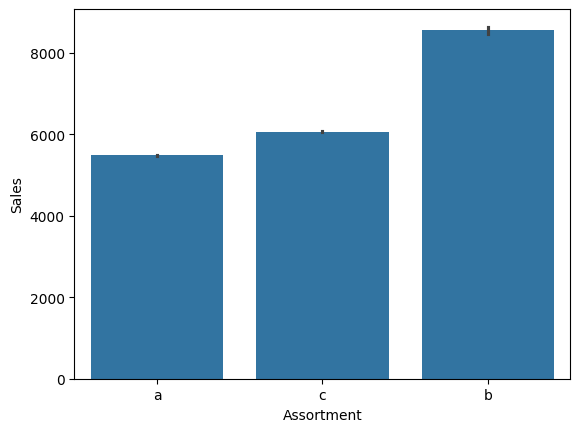

In [47]:
sns.barplot(data=df,x='Assortment',y='Sales')

<Axes: xlabel='Promo2', ylabel='Sales'>

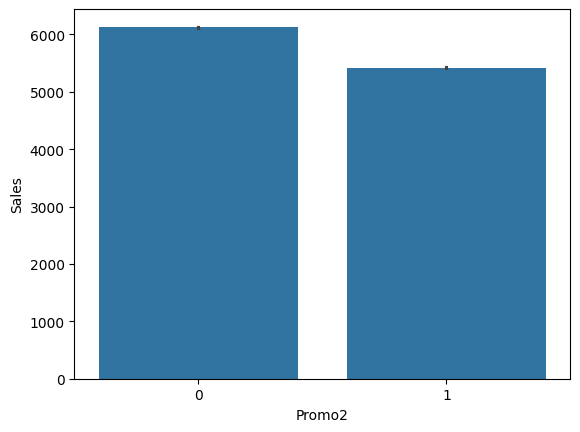

In [48]:
sns.barplot(data=df,x='Promo2',y='Sales')


--- Visualizing Missing Data Patterns ---


<Axes: >

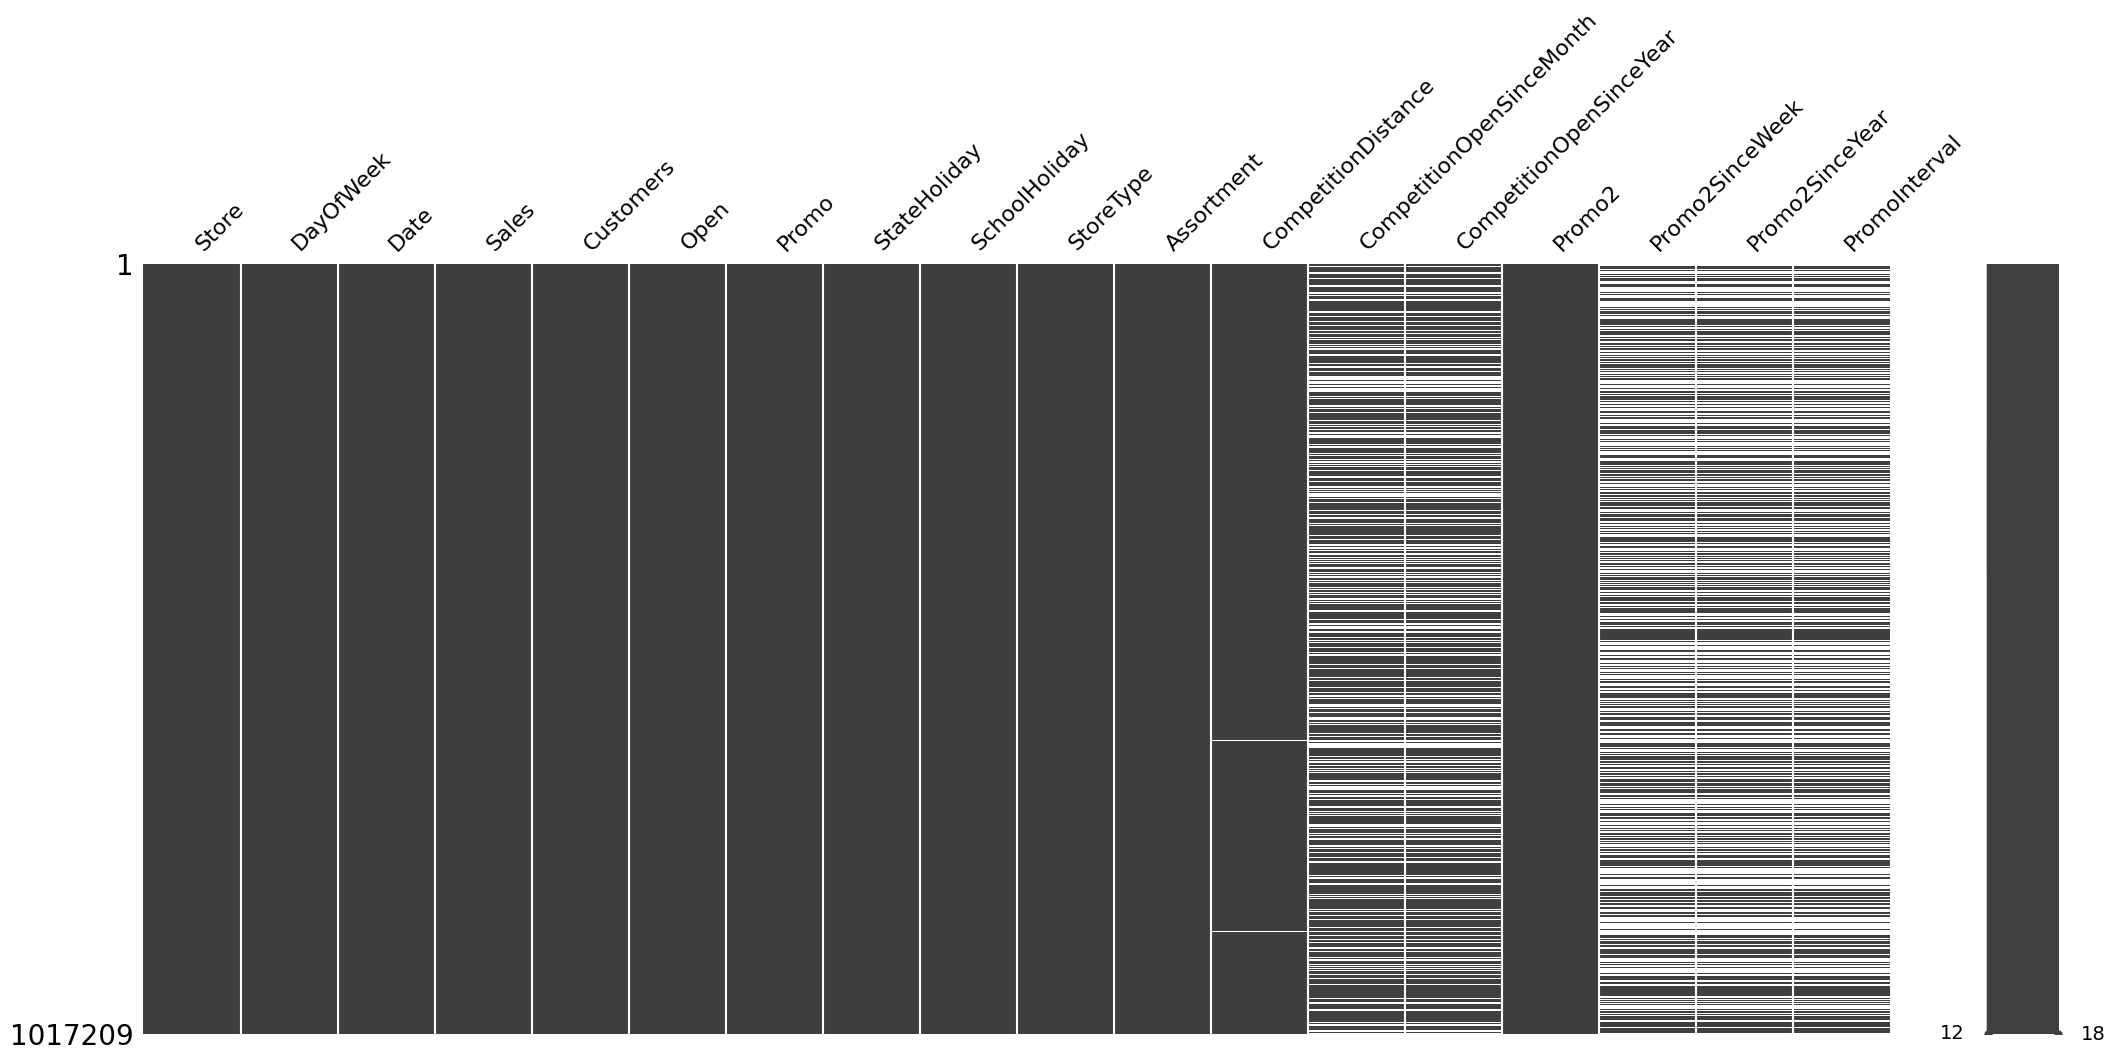

In [52]:
print("\n--- Visualizing Missing Data Patterns ---")
msno.matrix(df)

In [6]:
missing_values = ['CompetitionDistance','CompetitionOpenSinceMonth','CompetitionOpenSinceYear','Promo2SinceWeek','Promo2SinceYear','PromoInterval']
for col in missing_values:
    missing_per = df[col].isnull().mean()*100
    print(f'\n {col} : {missing_per}')


 CompetitionDistance : 0.25973030124586

 CompetitionOpenSinceMonth : 31.787764363075826

 CompetitionOpenSinceYear : 31.787764363075826

 Promo2SinceWeek : 49.94362023930186

 Promo2SinceYear : 49.94362023930186

 PromoInterval : 49.94362023930186


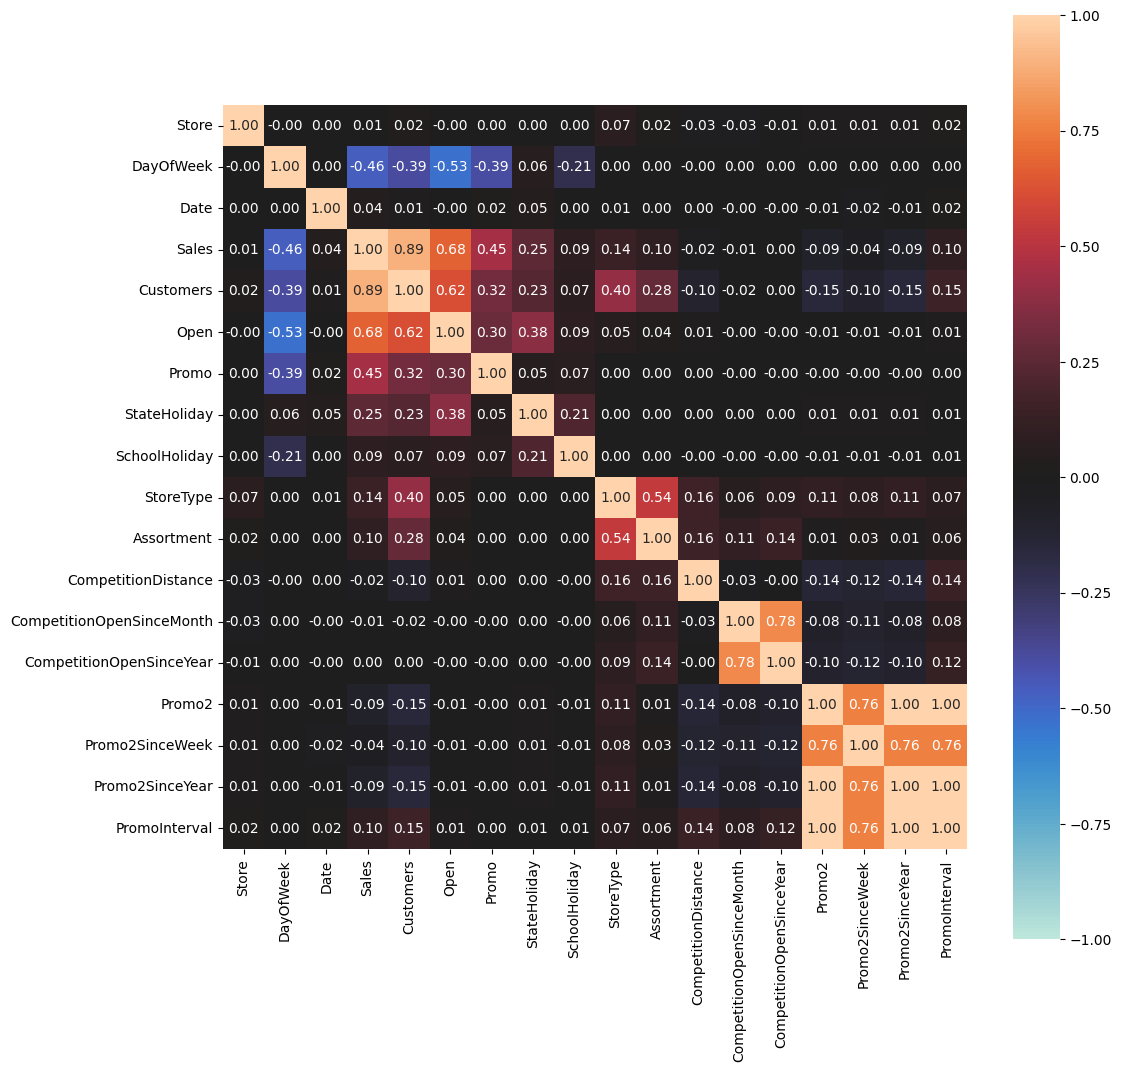

                              Store  DayOfWeek      Date     Sales  Customers  \
Store                      1.000000  -0.000008  0.000842  0.005126   0.024325   
DayOfWeek                 -0.000008   1.000000  0.000183 -0.462125  -0.386445   
Date                       0.000842   0.000183  1.000000  0.041904   0.012679   
Sales                      0.005126  -0.462125  0.041904  1.000000   0.894711   
Customers                  0.024325  -0.386445  0.012679  0.894711   1.000000   
Open                      -0.000047  -0.528963 -0.000157  0.678472   0.616768   
Promo                      0.000058  -0.392925  0.017249  0.452345   0.316169   
StateHoliday               0.003746   0.058497  0.045698  0.254424   0.226784   
SchoolHoliday              0.000641  -0.205388  0.001068  0.085124   0.071568   
StoreType                  0.071211   0.000075  0.006476  0.140390   0.399784   
Assortment                 0.019802   0.000052  0.004388  0.099223   0.275959   
CompetitionDistance       -0

In [59]:
results = associations(df, figsize=(12, 12))
mixed_corr_matrix = results['corr']
print(mixed_corr_matrix)

In [62]:
weird = ((df['Open'] == 1) & (df['Sales'] == 0)).sum()
weird

np.int64(54)

In [7]:
df[df['Promo2'] == 0][['Promo2SinceWeek','Promo2SinceYear','PromoInterval']].isna().mean()

Promo2SinceWeek    1.0
Promo2SinceYear    1.0
PromoInterval      1.0
dtype: float64

In [8]:
df['Promo2SinceWeek'].value_counts()

Promo2SinceWeek
14.0    72990
40.0    62598
31.0    39976
10.0    38828
5.0     35818
37.0    32786
1.0     32418
13.0    29820
45.0    29268
22.0    28694
18.0    27318
35.0    22814
9.0     12452
27.0     9626
36.0     9236
48.0     8294
39.0     4732
23.0     4342
44.0     2642
26.0      942
6.0       942
50.0      942
28.0      942
49.0      758
Name: count, dtype: int64

In [9]:
df['Promo2SinceYear'].value_counts()

Promo2SinceYear
2011.0    115056
2013.0    110464
2014.0     79922
2012.0     73174
2009.0     65270
2010.0     56240
2015.0      9052
Name: count, dtype: int64

In [10]:
df['PromoInterval'].value_counts()

PromoInterval
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64